# Toxicity and Sentiment Analysis of Wikipedia Comments

## Importing neccesary libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import streamlit as st

# Download necessary NLTK data (run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Loading

In [ ]:
# Load the dataset
df = pd.read_csv("/content/train (1).csv", encoding='latin1', on_bad_lines='skip', engine='python')

# Define the target columns for toxicity classification
target_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print("Dataset loaded successfully.")
print(f"Initial shape: {df.shape}")
display(df.head())
display(df.info())

Dataset loaded successfully.
Initial shape: (166004, 43)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166004 entries, 0 to 166003
Data columns (total 43 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             164444 non-null  object 
 1   comment_text   160910 non-null  object 
 2   toxic          159999 non-null  object 
 3   severe_toxic   159772 non-null  object 
 4   obscene        159654 non-null  object 
 5   threat         159571 non-null  object 
 6   insult         159533 non-null  object 
 7   identity_hate  159196 non-null  object 
 8   Unnamed: 8     308 non-null     object 
 9   Unnamed: 9     145 non-null     object 
 10  Unnamed: 10    87 non-null      object 
 11  Unnamed: 11    58 non-null      object 
 12  Unnamed: 12    36 non-null      object 
 13  Unnamed: 13    29 non-null      object 
 14  Unnamed: 14    18 non-null      object 
 15  Unnamed: 15    14 non-null      object 
 16  Unnamed: 16    10 non-null      object 
 17  Unnamed: 17    8 non-null    

None

Dataset loaded successfully.
Initial shape: (166004, 43)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166004 entries, 0 to 166003
Data columns (total 43 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             164444 non-null  object 
 1   comment_text   160910 non-null  object 
 2   toxic          159999 non-null  object 
 3   severe_toxic   159772 non-null  object 
 4   obscene        159654 non-null  object 
 5   threat         159571 non-null  object 
 6   insult         159533 non-null  object 
 7   identity_hate  159196 non-null  object 
 8   Unnamed: 8     308 non-null     object 
 9   Unnamed: 9     145 non-null     object 
 10  Unnamed: 10    87 non-null      object 
 11  Unnamed: 11    58 non-null      object 
 12  Unnamed: 12    36 non-null      object 
 13  Unnamed: 13    29 non-null      object 
 14  Unnamed: 14    18 non-null      object 
 15  Unnamed: 15    14 non-null      object 
 16  Unnamed: 16    10 non-null      object 
 17  Unnamed: 17    8 non-null    

None

### Cleaning Unnamed Columns and Converting Target Types



In [ ]:
# Drop 'Unnamed' columns.
columns_to_drop = [col for col in df.columns if 'Unnamed:' in col]
df = df.drop(columns=columns_to_drop)

# Convert target columns to numeric, coercing errors and filling NaNs with 0.
# This ensures they are binary (0 or 1) indicators.
for col in target_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(f"Shape after dropping 'Unnamed' columns and cleaning target types: {df.shape}")
display(df.head())
display(df.info())

Shape after dropping 'Unnamed' columns and cleaning target types: (166004, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166004 entries, 0 to 166003
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             164444 non-null  object
 1   comment_text   160910 non-null  object
 2   toxic          166004 non-null  int64 
 3   severe_toxic   166004 non-null  int64 
 4   obscene        166004 non-null  int64 
 5   threat         166004 non-null  int64 
 6   insult         166004 non-null  int64 
 7   identity_hate  166004 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 10.1+ MB


None

Shape after dropping 'Unnamed' columns and cleaning target types: (166004, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166004 entries, 0 to 166003
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             164444 non-null  object
 1   comment_text   160910 non-null  object
 2   toxic          166004 non-null  int64 
 3   severe_toxic   166004 non-null  int64 
 4   obscene        166004 non-null  int64 
 5   threat         166004 non-null  int64 
 6   insult         166004 non-null  int64 
 7   identity_hate  166004 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 10.1+ MB


None

## Text Preprocessing

In [ ]:
# Text Preprocessing Function
def clean_text(text):
    text = str(text) # Ensure text is a string to handle non-string types like float (NaN)
    text = text.lower() # Convert to lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+|\#', '', text) # Remove mentions and hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters and numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply cleaning and fill NaN in 'comment_text' with empty strings before processing
df['cleaned_text'] = df['comment_text'].fillna('').apply(clean_text)

print("Text cleaning complete. Displaying first 5 cleaned comments:")
for i, comment in enumerate(df['cleaned_text'].head()):
    print(f"Comment {i+1}: {comment}")

Text cleaning complete. Displaying first 5 cleaned comments:
Comment 1: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since im retired
Comment 2: daww match background colour im seemingly stuck thanks talk january utc
Comment 3: hey man im really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info
Comment 4: cant make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidying exact format ie date format etc later noone else first preference formatting style reference want please let know appears backlog article review guess may delay reviewer turn listed relevant form eg wikipediagoodarticlenominationstransport
Comment 5: sir hero chance remember page thats
Text cleaning complete. Displaying first 5 cleaned comments:
Comment 1: explanation edits 

## Sentiment Analysis

In [ ]:
# Function to get sentiment label based on VADER's compound score
def get_sentiment(text):
    score = sia.polarity_scores(text)
    if score['compound'] >= 0.05:
        return 'Positive'
    elif score['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to the cleaned text
df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

print("Sentiment analysis complete. Distribution of sentiments:")
display(df['sentiment'].value_counts())

Sentiment analysis complete. Distribution of sentiments:


,count
sentiment,
Positive,81805
Negative,49583
Neutral,34616


Sentiment analysis complete. Distribution of sentiments:


,count
sentiment,
Positive,81805
Negative,49583
Neutral,34616


### Distribution of Sentiment in Comments

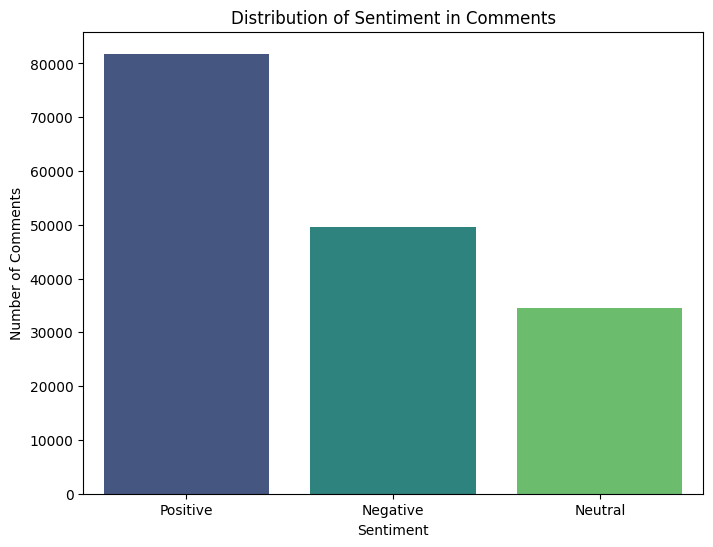

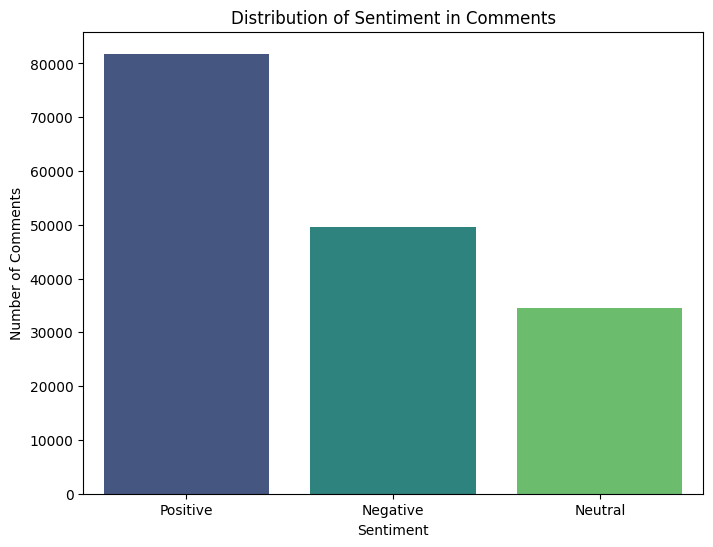

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis', hue='sentiment', legend=False)
plt.title('Distribution of Sentiment in Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

## Exploratory Data Analysis (EDA)

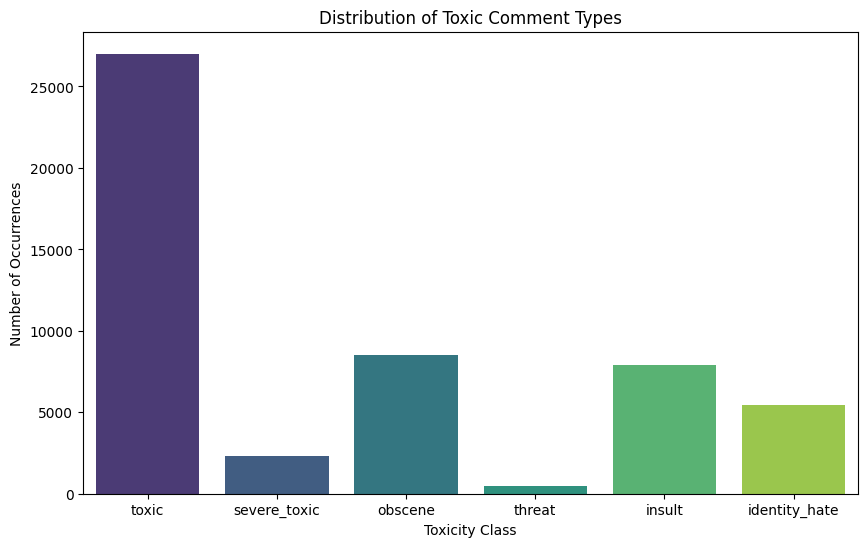

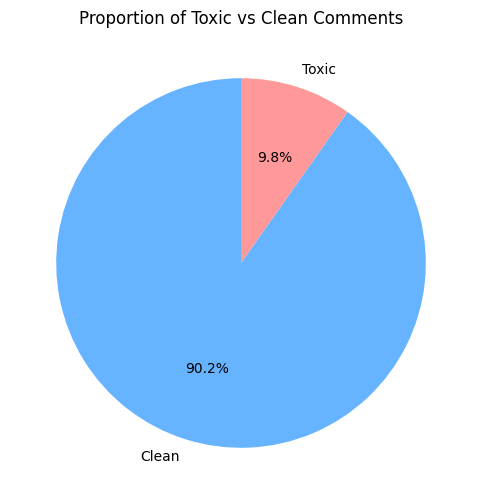

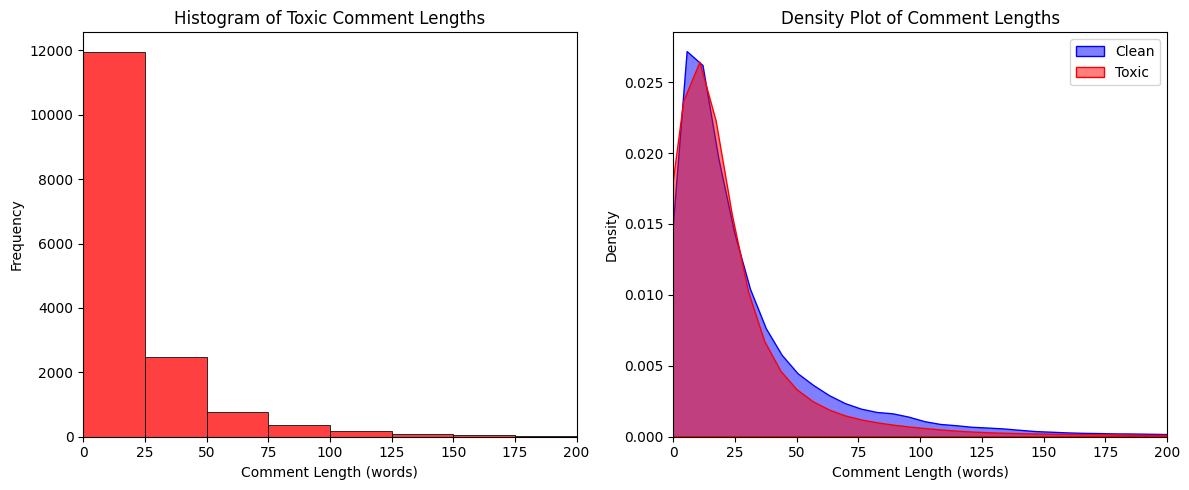

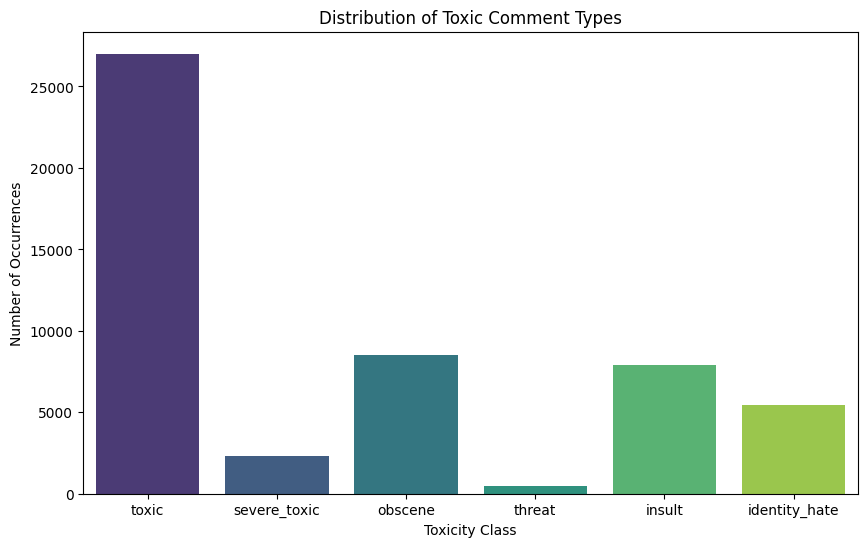

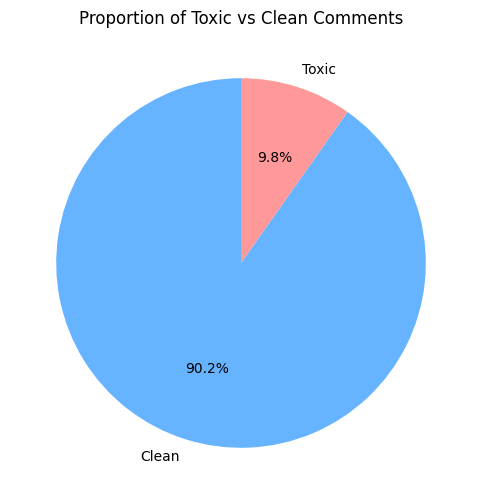

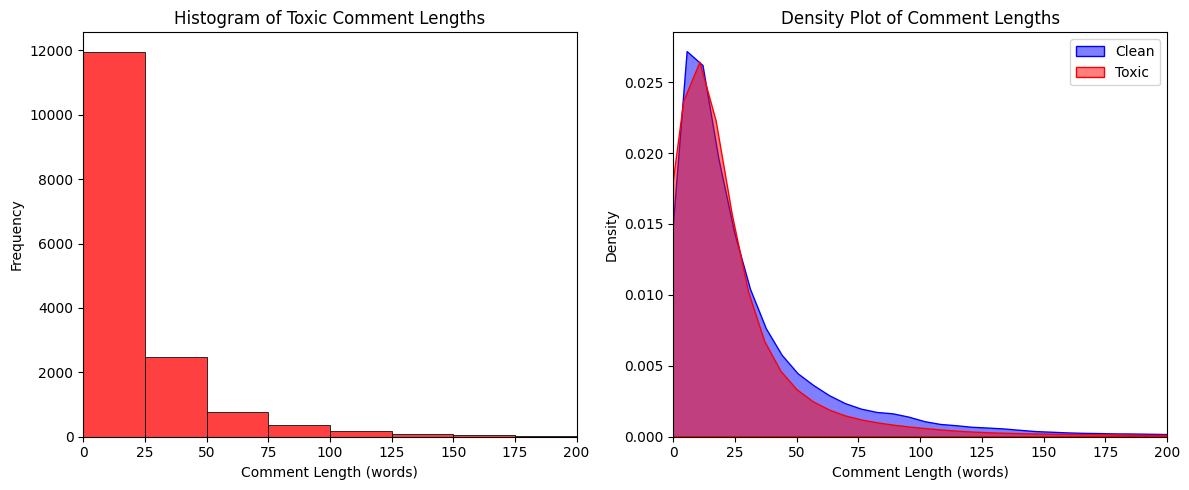

In [ ]:
# 1. Barplot: Frequencies of each toxicity class
plt.figure(figsize=(10, 6))
class_counts = df[target_columns].sum()
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', hue=class_counts.index, legend=False)
plt.title('Distribution of Toxic Comment Types')
plt.ylabel('Number of Occurrences')
plt.xlabel('Toxicity Class')
plt.show()

# 2. Pie-plot: Toxic vs Clean comments
# Create a new column 'is_toxic' which is 1 if any toxicity flag is true, else 0
df['is_toxic'] = (df[target_columns].sum(axis=1) > 0).astype(int)
toxic_counts = df['is_toxic'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(toxic_counts, labels=['Clean', 'Toxic'], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Proportion of Toxic vs Clean Comments')
plt.show()

# 3. Histogram & Density Plot: Comment Length Analysis
df['comment_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[df['is_toxic']==1]['comment_length'], bins=50, color='red', label='Toxic', kde=False)
plt.title('Histogram of Toxic Comment Lengths')
plt.xlabel('Comment Length (words)')
plt.ylabel('Frequency')
plt.xlim(0, 200) # Limit x-axis for better visualization

# Density Plot
plt.subplot(1, 2, 2)
sns.kdeplot(df[df['is_toxic']==0]['comment_length'], fill=True, color='blue', label='Clean', alpha=0.5)
sns.kdeplot(df[df['is_toxic']==1]['comment_length'], fill=True, color='red', label='Toxic', alpha=0.5)
plt.title('Density Plot of Comment Lengths')
plt.xlabel('Comment Length (words)')
plt.ylabel('Density')
plt.xlim(0, 200) # Limit x-axis for better visualization
plt.legend()
plt.tight_layout()
plt.show()

### Word Frequency and N-grams

To further understand the content, let's analyze the most frequent words and N-grams (sequences of words) in both toxic and clean comments. This can highlight specific vocabulary associated with each category.

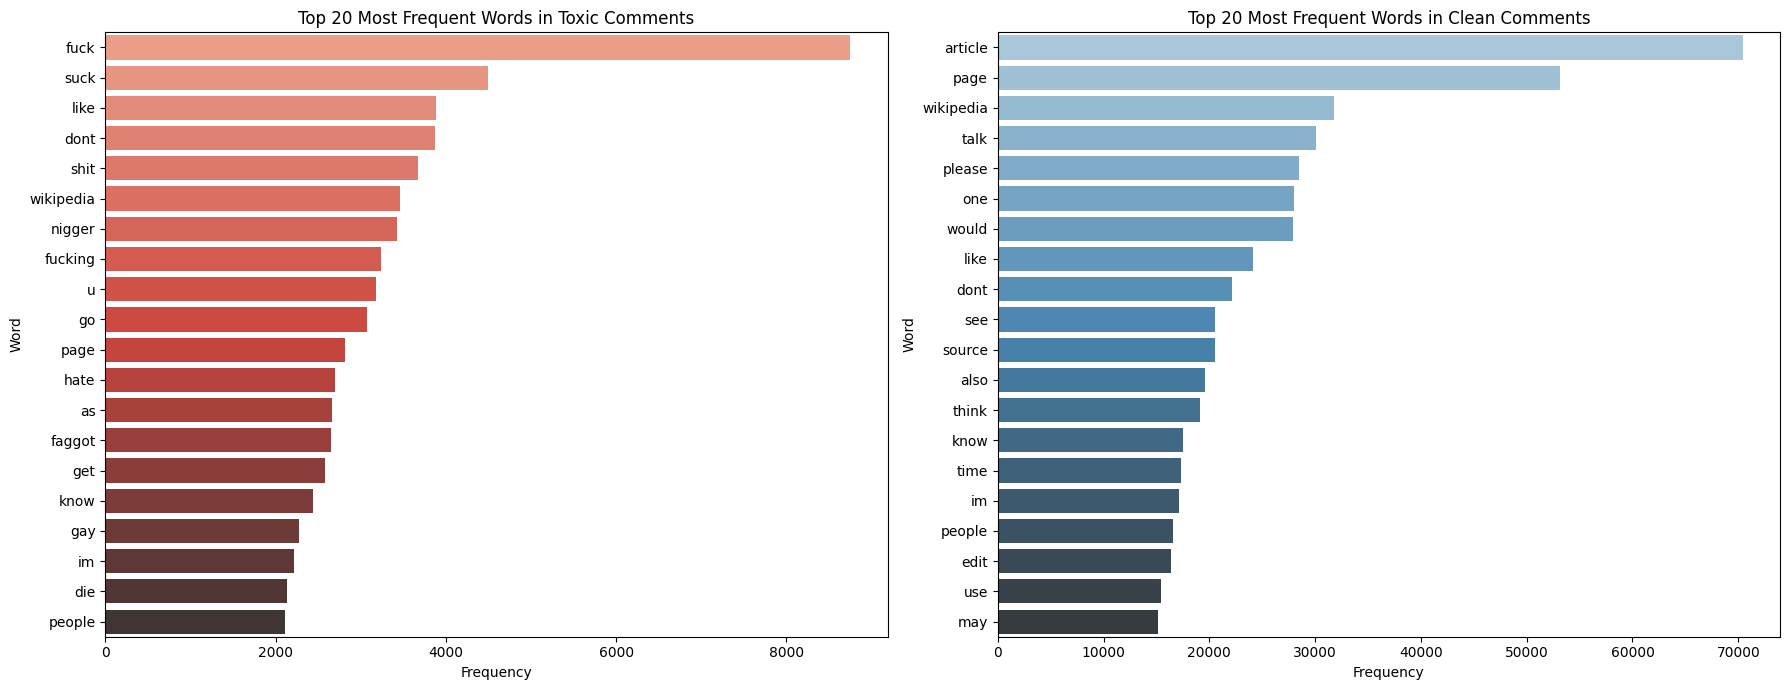

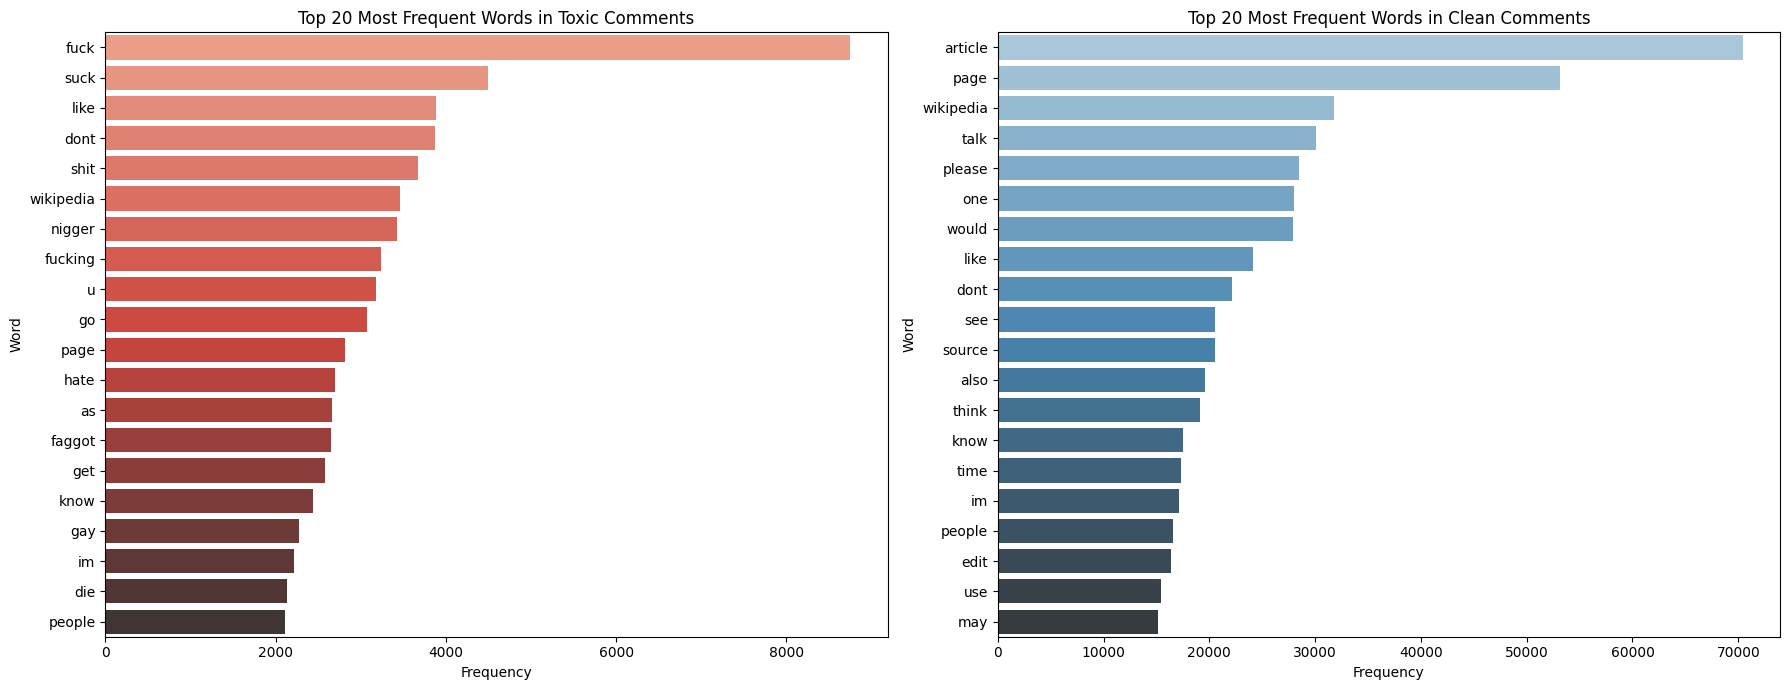

In [ ]:
def get_top_n_words(corpus, n=None):
    words = ' '.join(corpus).split()
    return Counter(words).most_common(n)

# Top 20 most frequent words in toxic comments
toxic_words = get_top_n_words(df[df['is_toxic'] == 1]['cleaned_text'], 20)
toxic_words_df = pd.DataFrame(toxic_words, columns=['Word', 'Frequency'])

# Top 20 most frequent words in clean comments
clean_words = get_top_n_words(df[df['is_toxic'] == 0]['cleaned_text'], 20)
clean_words_df = pd.DataFrame(clean_words, columns=['Word', 'Frequency'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Frequency', y='Word', data=toxic_words_df.sort_values(by='Frequency', ascending=False), ax=axes[0], palette='Reds_d', hue='Word', legend=False)
axes[0].set_title('Top 20 Most Frequent Words in Toxic Comments')

sns.barplot(x='Frequency', y='Word', data=clean_words_df.sort_values(by='Frequency', ascending=False), ax=axes[1], palette='Blues_d', hue='Word', legend=False)
axes[1].set_title('Top 20 Most Frequent Words in Clean Comments')

plt.tight_layout()
plt.show()

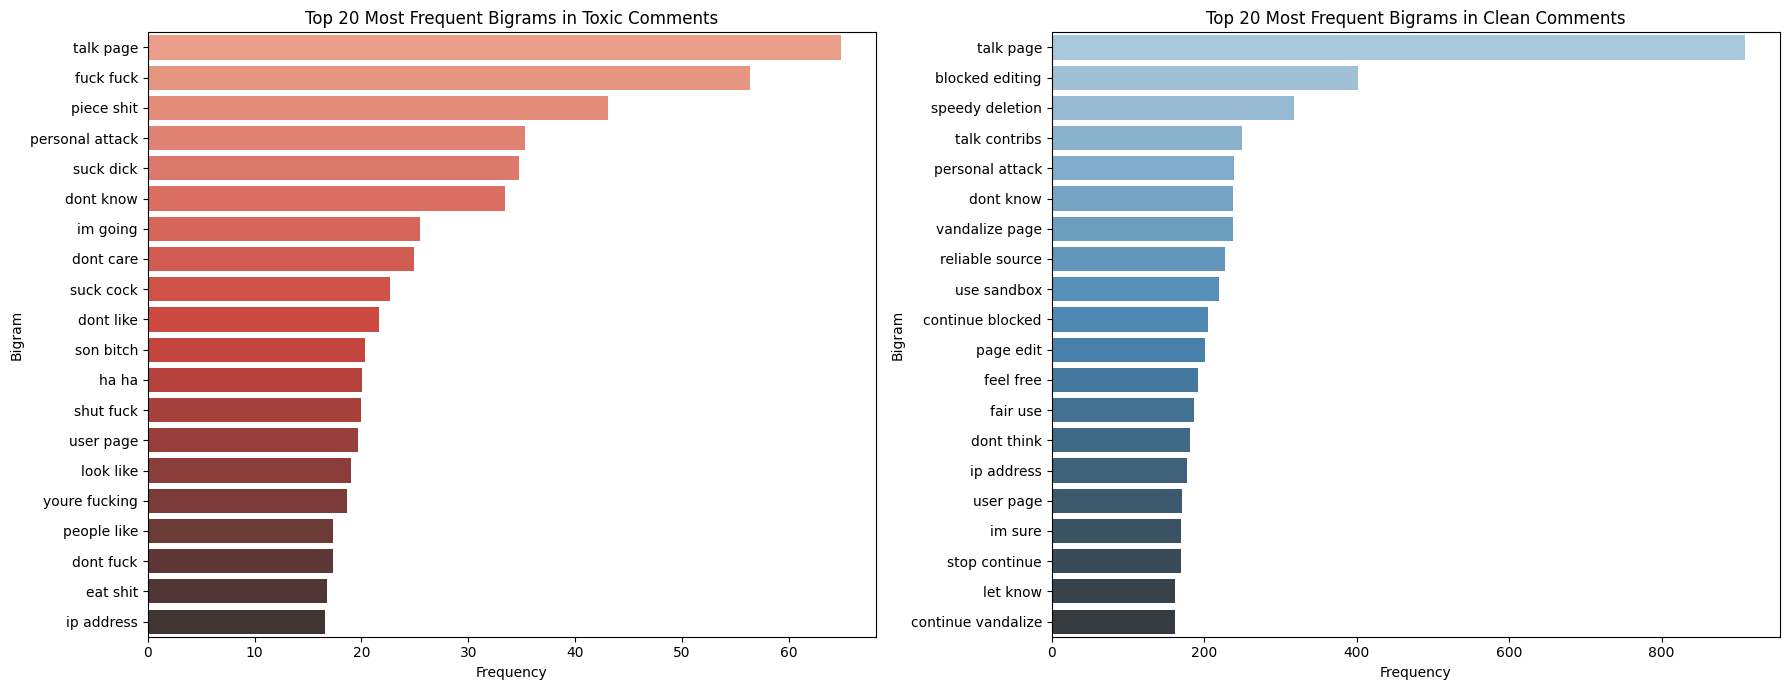

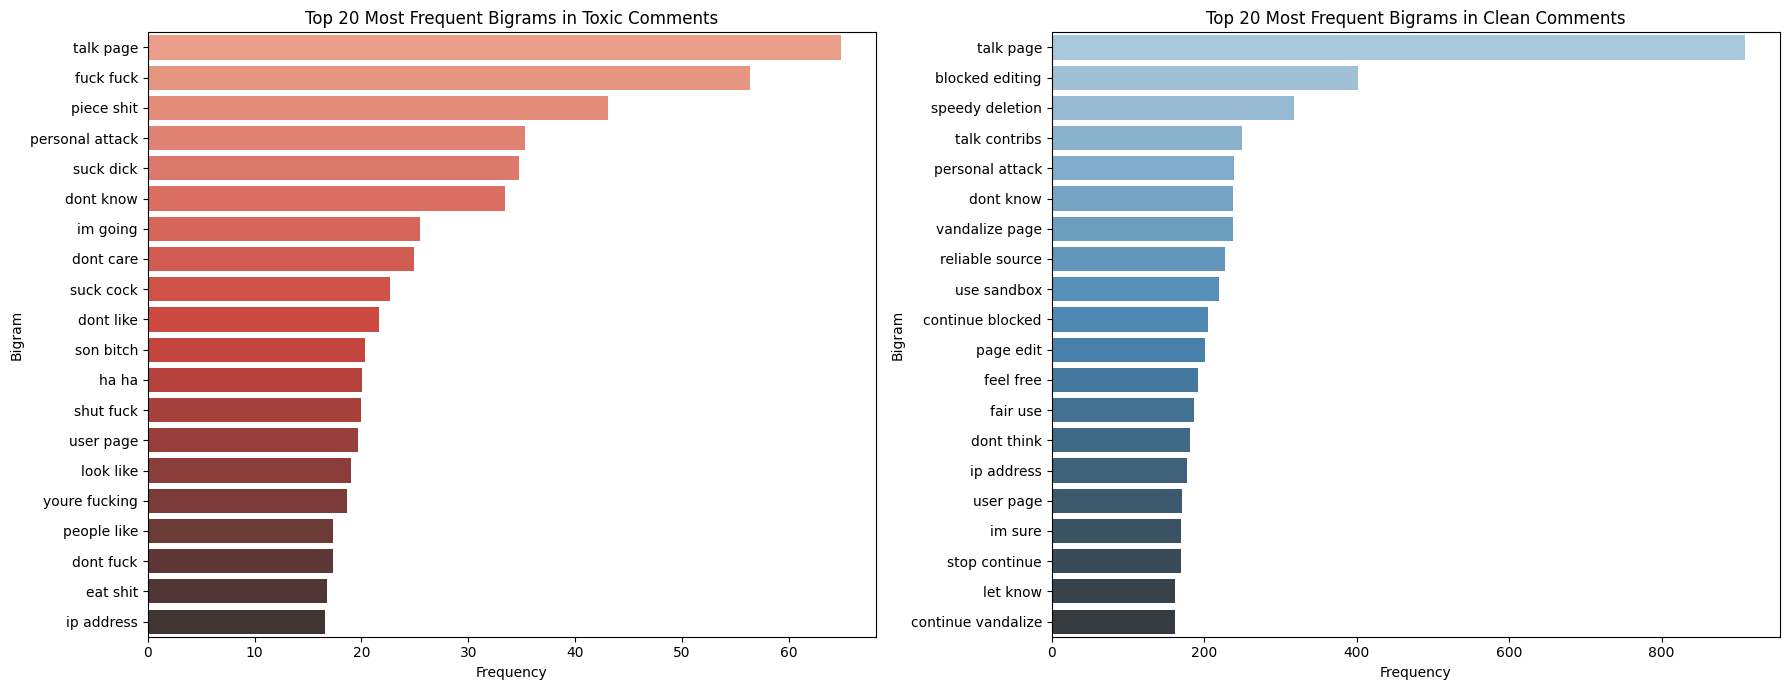

In [ ]:
def get_top_n_ngrams(corpus, ngrams=2, n=None):
    # Using TfidfVectorizer for n-gram extraction, filtering out common stopwords
    vectorizer = TfidfVectorizer(ngram_range=(ngrams, ngrams), stop_words='english')
    X = vectorizer.fit_transform(corpus)
    feature_names = vectorizer.get_feature_names_out()
    sums = X.sum(axis=0)
    data = []
    for col, term in enumerate(feature_names):
        data.append((term, sums[0, col]))
    ranked_features = sorted(data, key=lambda x: x[1], reverse=True)
    return ranked_features[:n]

# Top 20 most frequent bigrams in toxic comments
toxic_bigrams = get_top_n_ngrams(df[df['is_toxic'] == 1]['cleaned_text'], ngrams=2, n=20)
toxic_bigrams_df = pd.DataFrame(toxic_bigrams, columns=['Bigram', 'Frequency'])

# Top 20 most frequent bigrams in clean comments
clean_bigrams = get_top_n_ngrams(df[df['is_toxic'] == 0]['cleaned_text'], ngrams=2, n=20)
clean_bigrams_df = pd.DataFrame(clean_bigrams, columns=['Bigram', 'Frequency'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Frequency', y='Bigram', data=toxic_bigrams_df.sort_values(by='Frequency', ascending=False), ax=axes[0], palette='Reds_d', hue='Bigram', legend=False)
axes[0].set_title('Top 20 Most Frequent Bigrams in Toxic Comments')

sns.barplot(x='Frequency', y='Bigram', data=clean_bigrams_df.sort_values(by='Frequency', ascending=False), ax=axes[1], palette='Blues_d', hue='Bigram', legend=False)
axes[1].set_title('Top 20 Most Frequent Bigrams in Clean Comments')

plt.tight_layout()
plt.show()

### Word Clouds

Word clouds provide a visual representation of word frequency. Larger words in the cloud indicate higher frequency. Let's generate word clouds for toxic and clean comments to quickly grasp their dominant vocabulary.

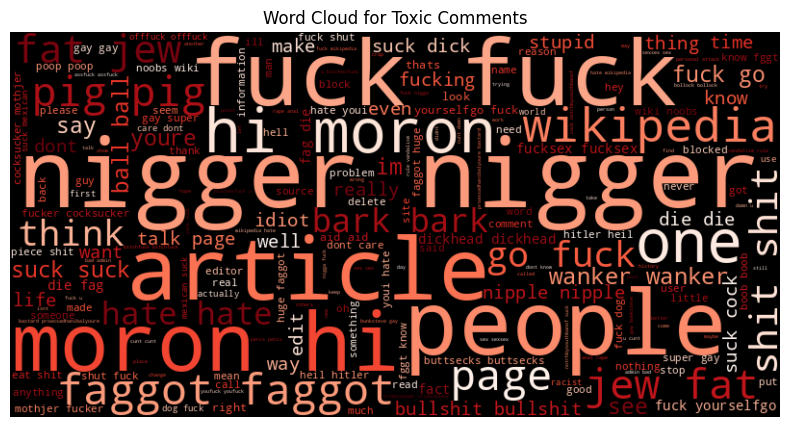

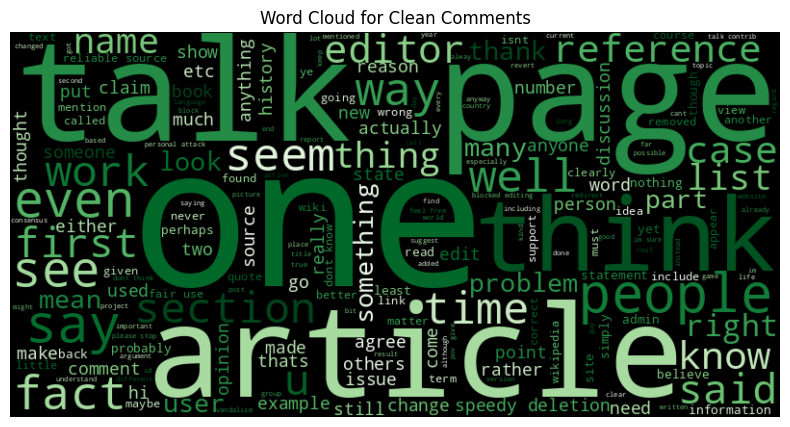

In [ ]:
# Word Cloud for Toxic Comments
toxic_text = " ".join(df[df['is_toxic'] == 1]['cleaned_text'].dropna())
wordcloud_toxic = WordCloud(width=800, height=400, background_color='black',colormap='Reds').generate(toxic_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_toxic, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Toxic Comments')
plt.show()

# Word Cloud for Clean Comments
clean_text = " ".join(df[df['is_toxic'] == 0]['cleaned_text'].dropna())
wordcloud_clean = WordCloud(width=800, height=400, background_color='black',colormap='Greens').generate(clean_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Clean Comments')
plt.show()

## Model Training and Evaluation

This section focuses on training and evaluating multi-label classification models to predict toxicity. We will use:
1.  **TF-IDF Vectorization:** To convert text data into numerical features.
2.  **Train-Test Split:** To divide the data into training and testing sets.
3.  **OneVsRestClassifier:** To handle the multi-label nature of the target variables with base estimators like Logistic Regression and Linear Support Vector Classifier (LinearSVC).
4.  **Model Evaluation:** Using classification reports and confusion matrices to assess performance.
5.  **Model Saving:** Persisting the trained model and vectorizer for future deployment.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df[target_columns], test_size=0.2, random_state=42
)

# Convert y_train and y_test to boolean numpy arrays to explicitly define them as multi-label indicators
# This ensures compatibility with OneVsRestClassifier and various metrics.
y_train = y_train.values.astype(bool)
y_test = y_test.values.astype(bool)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# TF-IDF Vectorization: Convert text into a matrix of TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nText vectorized using TF-IDF.")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")

Data split into training and testing sets.
X_train shape: (132803,), y_train shape: (132803, 6)
X_test shape: (33201,), y_test shape: (33201, 6)

Text vectorized using TF-IDF.
X_train_tfidf shape: (132803, 5000)
X_test_tfidf shape: (33201, 5000)


In [ ]:
# Initialize Models wrapped with OneVsRestClassifier for multi-label classification
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='liblinear'))
# LinearSVC is suitable for large datasets, dual=False is recommended when n_samples > n_features
svm_model = OneVsRestClassifier(LinearSVC(dual=False))

# --- Train and Evaluate Logistic Regression ---
print("\n--- Logistic Regression Results ---")
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)

print(f"Accuracy Score (Logistic Regression): {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr, target_names=target_columns))

# --- Train and Evaluate SVM ---
print("\n--- Support Vector Machine (LinearSVC) Results ---")
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print(f"Accuracy Score (SVM): {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred_svm, target_names=target_columns))



--- Logistic Regression Results ---
Accuracy Score (Logistic Regression): 0.9240

Classification Report (Logistic Regression):
                precision    recall  f1-score   support

        toxic       0.90      0.61      0.73      2979
 severe_toxic       0.54      0.23      0.32       319
      obscene       0.91      0.66      0.76      1643
       threat       0.72      0.13      0.23        97
       insult       0.82      0.53      0.64      1551
identity_hate       0.72      0.23      0.35       274

    micro avg       0.87      0.57      0.69      6863
    macro avg       0.77      0.40      0.51      6863
 weighted avg       0.86      0.57      0.68      6863
  samples avg       0.05      0.05      0.05      6863


--- Support Vector Machine (LinearSVC) Results ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy Score (SVM): 0.9243

Classification Report (SVM):
                precision    recall  f1-score   support

        toxic       0.87      0.66      0.75      2979
 severe_toxic       0.55      0.23      0.32       319
      obscene       0.89      0.70      0.79      1643
       threat       0.68      0.20      0.30        97
       insult       0.80      0.57      0.67      1551
identity_hate       0.69      0.27      0.39       274

    micro avg       0.85      0.61      0.71      6863
    macro avg       0.75      0.44      0.54      6863
 weighted avg       0.84      0.61      0.70      6863
  samples avg       0.06      0.05      0.05      6863



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Based on the classification reports, SVM (LinearSVC) generally shows slightly better performance (e.g., F1-scores)
joblib.dump(svm_model, 'toxicity_svm_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("\nSaved 'toxicity_svm_model.pkl' (SVM model) and 'tfidf_vectorizer.pkl' for deployment.")


Saved 'toxicity_svm_model.pkl' (SVM model) and 'tfidf_vectorizer.pkl' for deployment.


### Confusion Matrices for SVM Model

Since this is a multi-label classification problem, a single confusion matrix for all labels is not straightforward. Instead, we generate:
1.  **Individual Confusion Matrices (per label):** To see the performance of the SVM model for each specific toxicity category.
2.  **Overall Confusion Matrix (Clean vs. Toxic):** To get a consolidated view of how well the model differentiates between any toxic comment and a completely clean comment.


--- Confusion Matrices for SVM (per label) ---


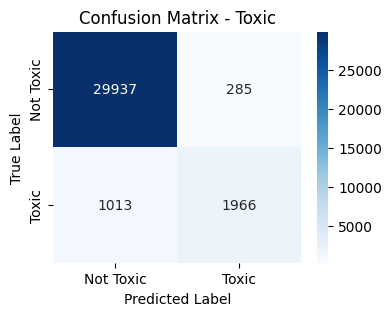

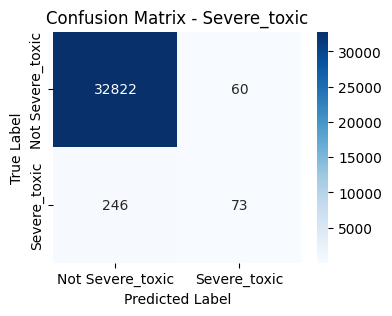

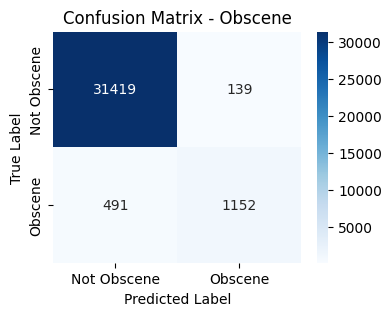

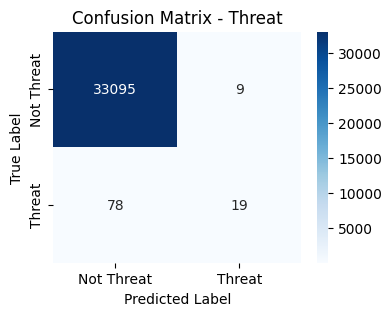

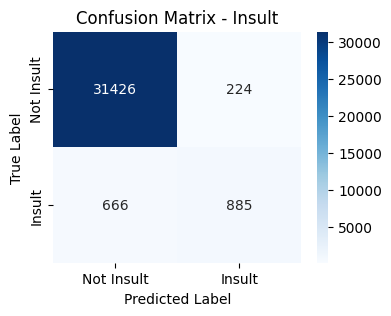

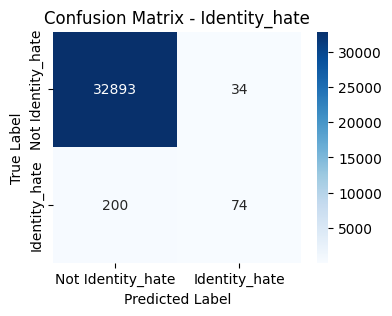


--- Overall Confusion Matrix (Toxic vs. Clean) for SVM ---


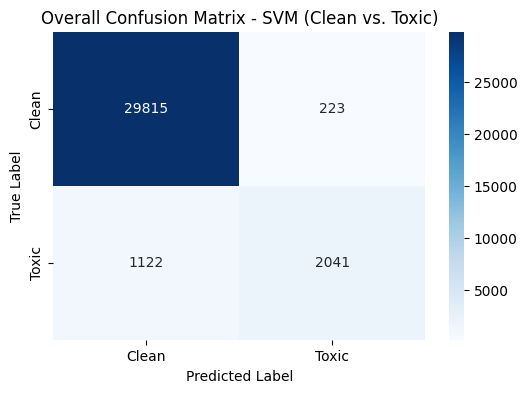

In [ ]:
# --- Confusion Matrices for SVM (per label) ---
print("\n--- Confusion Matrices for SVM (per label) ---")

for i, label in enumerate(target_columns):
    # Generate confusion matrix for each individual label
    cm = confusion_matrix(y_test[:, i], y_pred_svm[:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Not {label.capitalize()}', label.capitalize()],
                yticklabels=[f'Not {label.capitalize()}', label.capitalize()])
    plt.title(f'Confusion Matrix - {label.capitalize()}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# --- Overall Confusion Matrix (Toxic vs. Clean) for SVM ---
print("\n--- Overall Confusion Matrix (Toxic vs. Clean) for SVM ---")

# A comment is considered 'toxic' if at least one toxicity label is true (sum > 0)
is_toxic_true = (y_test.sum(axis=1) > 0).astype(int)
# A comment is predicted 'toxic' if at least one toxicity label is predicted true
is_toxic_pred_svm = (y_pred_svm.sum(axis=1) > 0).astype(int)

overall_cm = confusion_matrix(is_toxic_true, is_toxic_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean', 'Toxic'],
            yticklabels=['Clean', 'Toxic'])
plt.title('Overall Confusion Matrix - SVM (Clean vs. Toxic)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Streamlit Application and production

In [ ]:
### Streamlit Application Download

In [ ]:


streamlit_code = '''
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from math import exp # Import exp for sigmoid function

# Ensure NLTK data is downloaded for the Streamlit app context if run separately
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Initialize NLTK components for the app
stop_words_app = set(stopwords.words('english'))
lemmatizer_app = WordNetLemmatizer()

# Load saved model and vectorizer
# Assuming the saved model is 'toxicity_svm_model.pkl'
model_app = joblib.load('toxicity_svm_model.pkl')
vectorizer_app = joblib.load('tfidf_vectorizer.pkl')
# Define target classes directly in the app for self-containment
target_classes_app = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

def clean_text_app(text):
    text = str(text).lower() # Ensure text is a string
    text = re.sub(r"http\\S+|www\\S+|https\\S+", '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'[^a-zA-Z\\s]', '', text) # Remove special characters and numbers
    text = re.sub(r'\\s+', ' ', text).strip() # Remove extra spaces

    # Remove stopwords and lemmatize
    tokens = [lemmatizer_app.lemmatize(word) for word in text.split() if word not in stop_words_app]
    return " ".join(tokens)

# Streamlit UI
st.title("🛡️Toxicity Comment Classifier")
st.write("Enter a comment below to check for various toxicity types.")

user_input = st.text_area("Enter Text:", height=150)

if st.button("Analyze Toxicity"):
    if user_input:
        with st.spinner("Analyzing text..."):
            # Clean and vectorize input text
            cleaned_input = clean_text_app(user_input)
            vectorized_input = vectorizer_app.transform([cleaned_input])

            # Predict toxicity labels
            predictions = model_app.predict(vectorized_input)[0]

            # Retrieve probabilities or confidence scores
            probabilities = None
            if hasattr(model_app, 'predict_proba') and callable(getattr(model_app, 'predict_proba')):
                try:
                    # For OneVsRestClassifier, predict_proba exists if the base estimator supports it
                    probabilities = model_app.predict_proba(vectorized_input)[0]
                except AttributeError:
                    pass # Base estimator does not have predict_proba

            if probabilities is None:
                # Fallback for models like LinearSVC that don't directly support predict_proba.
                # Using decision_function as a proxy for confidence, then scaling it.
                # For true probabilities, CalibratedClassifierCV should be used with LinearSVC.
                decision_scores = model_app.decision_function(vectorized_input)[0]
                # Simple scaling to roughly [0,1], for display purposes. Not true probabilities.
                # This is a heuristic: positive score -> toxic, negative -> not toxic.
                probabilities = [1 / (1 + exp(-score)) for score in decision_scores] # Sigmoid scaling

            st.subheader("Analysis Results:")

            # Display detected toxicity types
            is_toxic_overall = False
            for i, col in enumerate(target_classes_app):
                if predictions[i] == 1:
                    is_toxic_overall = True
                    # Display a warning with a scaled confidence score
                    st.error(f"⚠️ **{col.replace('_', ' ').capitalize()}** detected! (Confidence: {probabilities[i]*100:.2f}%) ")

            if not is_toxic_overall:
                st.success("✅ This text appears to be clean and safe!")

    else:
        st.warning("Please enter some text to analyze.")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

files.download('app.py')

print("app.py has been created and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

app.py has been created and downloaded.
